# **Inverse Modeling of Cartesian Model**
- ### **Condition**: low-resolution or noisy $S_g$ (time-lapse seismic monitoring)
- ### **Condition**: partial obervations of $S_g$ and $P$ (monitoring wells)
- ### **Condition**: partial obervations of $S_g$, $P$, and $K$ (monitoring wells and well logs)

In [1]:
%env CUDA_VISIBLE_DEVICES = 0
import torch
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
import sys
sys.path.append("../../../..")
from ConditionalDiffusionGeneration.src.guided_diffusion.unet import create_model
from ConditionalDiffusionGeneration.src.guided_diffusion.condition_methods import get_conditioning_method
from ConditionalDiffusionGeneration.src.guided_diffusion.measurements import get_noise, get_operator
from ConditionalDiffusionGeneration.src.guided_diffusion.gaussian_diffusion import create_sampler
from einops import rearrange

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    dev = "cuda"
else:
    dev = "cpu"

device = torch.device(dev)
print(device)

env: CUDA_VISIBLE_DEVICES=0
cuda


### Load Unconditional Model

In [2]:
u_net_model = create_model(image_size= 64,
                           num_channels= 64,
                           num_res_blocks= 2,
                           num_heads=8,
                           num_head_channels=32,
                           attention_resolutions="32,16,8,4,2,1",
                           channel_mult="1,1,2,2,4,4",
                           learn_sigma=True,
                           model_path='/ehome/zhao/nf/CoNFiLD/UnconditionalDiffusionTraining_and_Generation/output/logs_unet_experiment1/ema_0.9999_160000.pt'
                        )

u_net_model.to(device)
u_net_model.eval()
print('loaded unet')

loaded unet


## **Condition**: low-resolution or noisy $S_g$ (time-lapse seismic monitoring)

### Conditional Operator and Noise

In [3]:
operator =  get_operator(name='cartesian_superresolution',
                        device=device,
                        ckpt_path='/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/checkpoint_14996.pt',
                        norm_record_path='/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/normalizer_params.pt',
                        simdata_path='/ehome/zhao/nf/CoNFiLD/Dataset/Cartesian_all3_small.npy',
                        simdata_idx=1999,
                        ds_size=16,
                        vanilla_flag=True,
                        )

/ehome/zhao/nf/CoNFiLD/ConditionalDiffusionGeneration/inference_scripts/Case4/random_sensor/../../../../ConditionalDiffusionGeneration/src/guided_diffusion/measurements.py:754: UserWarning: Vanilla flag is set to True, using the original data without downsampling!
  warnings.warn(f"Vanilla flag is set to True, using the original data without downsampling!")


Simulation data loaded, with shape (64, 64, 64, 3)


In [4]:
noiser = get_noise(sigma=0.0, name='gaussian')

### Conditioning Method

In [ ]:
cond_method = get_conditioning_method(operator=operator, noiser=noiser, name='ps_adam', scale=1e-2)    # 1e-2
measurement_cond_fn = partial(cond_method.conditioning)

### Sampler

In [6]:
sampler = create_sampler(sampler='ddpm',
                         steps=1000,
                         noise_schedule="cosine",
                         model_mean_type="epsilon",
                         model_var_type="learned_range",
                         dynamic_threshold=False,
                         clip_denoised=True,
                         rescale_timesteps=False,
                         timestep_respacing="")

sample_fn = partial(sampler.p_sample_loop, model=u_net_model, measurement_cond_fn=measurement_cond_fn)

### Generate Samples

In [7]:
no_of_samples = 10
time_length = 64
latent_size = 256

In [8]:
x_start = torch.randn(no_of_samples, 1, time_length, latent_size, device=device)
measurement_ref = operator.sparse_cartesian_measurement()
samples = [sample_fn(x_start=x_start[i:i+1], measurement=measurement_ref, record=False, save_root=None) for i in range(x_start.shape[0])]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [9]:
gen_latents = torch.cat(samples)
gen_latents = operator._unnorm(gen_latents)
gen_latents = gen_latents[:,0]
print(f"Generated latents shape: {gen_latents.shape}")
torch.save(gen_latents, 'conditional_outputs/pts/generated_latents_Cart64xSR.pt')

Generated latents shape: torch.Size([10, 64, 256])


### Decoding latents to flow fields

In [10]:
from ConditionalNeuralField.cnf.nf_networks import SIRENAutodecoder_mdf_film
nf = SIRENAutodecoder_mdf_film(omega_0=5,
                                in_coord_features=2,
                                in_latent_features=256,
                                out_features=3,
                                num_hidden_layers=5,
                                hidden_features=128)
ckpt = torch.load("/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/checkpoint_14996.pt")
nf.load_state_dict(ckpt['model_state_dict'])
nf.eval()
nf.to(device)
del ckpt
print('nf loaded')

nf loaded


In [11]:
# gen_latents = torch.load('conditional_outputs/pts/generated_latents_Cart8xSR.pt')
whole_coords = operator._gene_cartesian_coord()
whole_coords_in = whole_coords.unsqueeze(0).to(device)
gen_latents_in = rearrange(gen_latents, 'b t l -> (b t) 1 1 l' )
gen_latents_in = gen_latents_in.to(device)
with torch.no_grad():
    nf_out_gene = nf(whole_coords_in, gen_latents_in)
nf_out_gene = operator._unnorm_cnf(nf_out_gene)
nf_out_gene = nf_out_gene.reshape(no_of_samples, time_length, 64, 64, 3)
print(f"CNF output shape: {nf_out_gene.shape}")
torch.save(nf_out_gene, 'conditional_outputs/pts/CNF_out_Cart64xSR.pt')

CNF output shape: torch.Size([10, 64, 64, 64, 3])


### ***Load pt records (CNF out & reference)***

In [12]:
sr4 = torch.load('conditional_outputs/pts/CNF_out_Cart4xSR.pt', map_location='cpu').detach().numpy()
sr8 = torch.load('conditional_outputs/pts/CNF_out_Cart8xSR.pt', map_location='cpu').detach().numpy()
sr16 = torch.load('conditional_outputs/pts/CNF_out_Cart16xSR.pt', map_location='cpu').detach().numpy()
sr64 = torch.load('conditional_outputs/pts/CNF_out_Cart64xSR.pt', map_location='cpu').detach().numpy()
ref = operator.simdata
print(f"Reference shape: {ref.shape}, CNF output shape: {sr16.shape}")

Reference shape: (64, 64, 64, 3), CNF output shape: (10, 64, 64, 64, 3)


*plot maps*

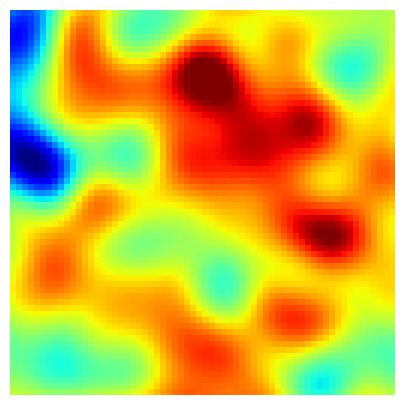

In [215]:
plt.figure(figsize=(5, 5))
plt.imshow(ref[0, :, :, -1], cmap='jet', vmin=1.5, vmax=6.5)
plt.axis('off')
# cbar = plt.colorbar(shrink=0.8)
# cbar.ax.tick_params(labelsize=10)
# cbar.set_label('$log(K)$', fontsize=12)
plt.savefig('conditional_outputs/figs/Ref_cart_K.pdf', bbox_inches='tight')

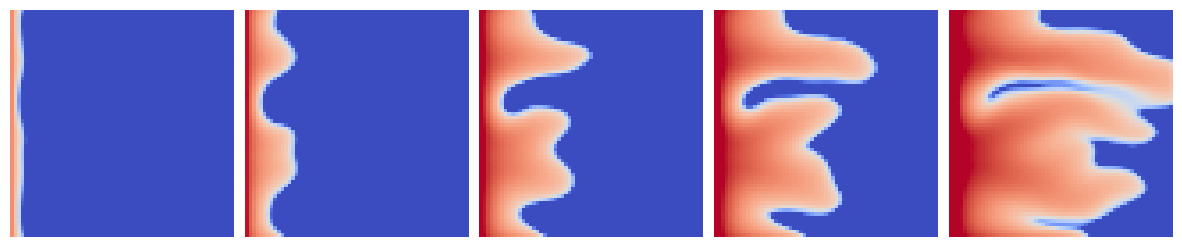

In [11]:
# time steps: 500 days / 64 steps = 7.8 days/step
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(ref[t, :, :-1, 1], cmap='coolwarm', vmin=0, vmax=0.5)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs/Ref_cart_Sg.pdf', bbox_inches='tight')

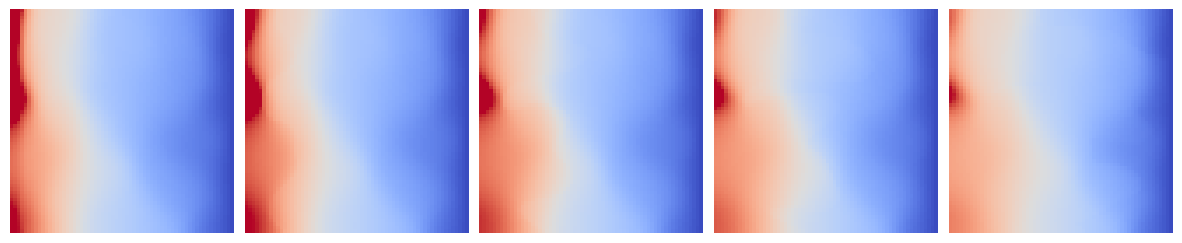

In [384]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(ref[t, :, :, 0]/1e6, cmap='coolwarm', vmin=12, vmax=15)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs/Ref_cart_P.pdf', bbox_inches='tight')

In [26]:
def downsample(numpy_array, ds_size):
    assert len(numpy_array.shape) >= 3, "Input array must have at least 3 dimensions"
    import torch.nn.functional as F
    ds_size = (ds_size, ds_size) if isinstance(ds_size, int) else tuple(ds_size)
    to_tensor = torch.from_numpy(numpy_array)
    print(f"Before downsample shape: {to_tensor.shape}")
    ds_tensor = F.interpolate(to_tensor, size=ds_size, mode='nearest')
    print(f"After downsample shape: {ds_tensor.shape}")
    return ds_tensor.numpy()

SR4 K shape: (10, 64, 64)


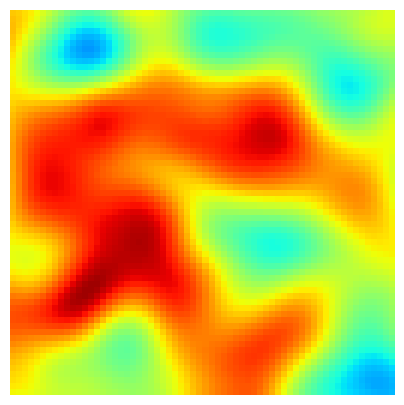

In [5]:
sr4_k = np.mean(sr4[..., -1], axis=1)
print(f"SR4 K shape: {sr4_k.shape}")
plt.figure(figsize=(5, 5))
plt.imshow(sr4_k[0, :, :], cmap='jet', vmin=1.5, vmax=6.5)
plt.axis('off')
plt.savefig('conditional_outputs/figs/Gene_cart_K_sr4.pdf', bbox_inches='tight')

Before downsample shape: torch.Size([10, 64, 64, 64])
After downsample shape: torch.Size([10, 64, 4, 4])
SR4 Sg shape: (10, 64, 64, 64), downsampled SR4 Sg shape: (10, 64, 4, 4)


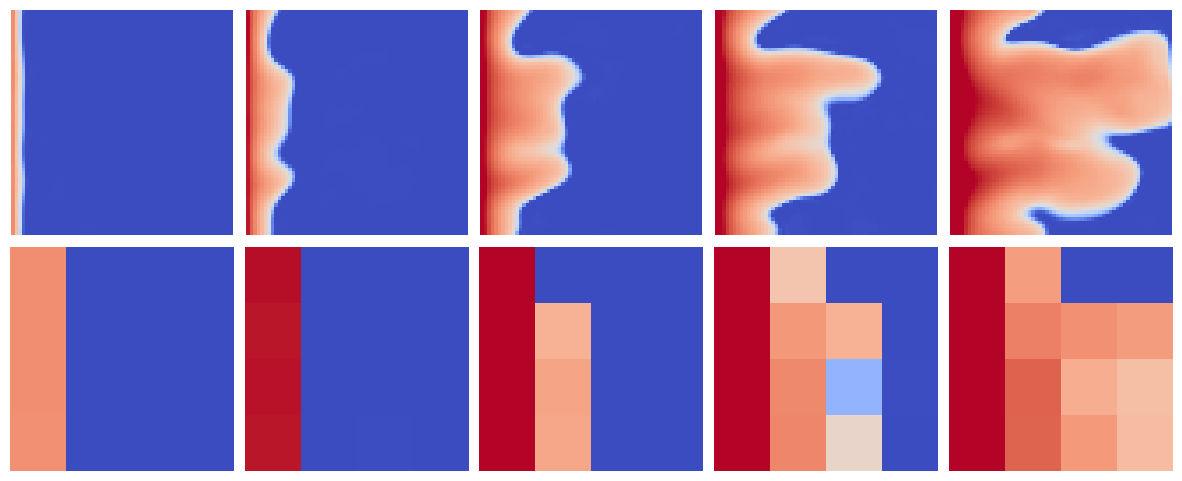

In [14]:
sr4_sg = sr4[..., 1]
sr4_sg_ds = downsample(sr4_sg, 4)
print(f"SR4 Sg shape: {sr4_sg.shape}, downsampled SR4 Sg shape: {sr4_sg_ds.shape}")
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    t = ts[i]
    ax[0, i].imshow(sr4_sg[0, t, :, :-1], cmap='coolwarm', vmin=0, vmax=0.5)
    ax[1, i].imshow(sr4_sg_ds[0, t, ...], cmap='coolwarm', vmin=0, vmax=0.5)
    ax[0, i].axis('off')
    ax[1, i].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig('conditional_outputs/figs/Gene_cart_Sg_sr4.pdf', bbox_inches='tight')

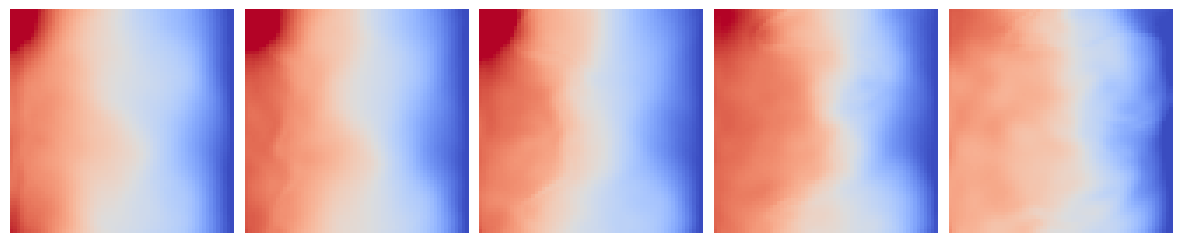

In [387]:
sr4_p = sr4[..., 0]
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(1, 5, figsize=(15, 6))
for i in range(5):
    t = ts[i]
    ax[i].imshow(sr4_p[0, t, :, :]/1e6, cmap='coolwarm', vmin=12, vmax=15)
    ax[i].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig('conditional_outputs/figs/Gene_cart_P_sr4.pdf', bbox_inches='tight')

SR8 K shape: (10, 64, 64)


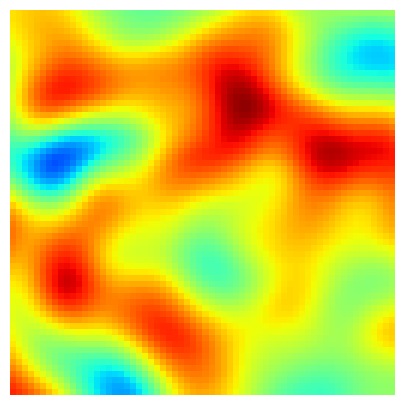

In [6]:
sr8_k = np.mean(sr8[..., -1], axis=1)
print(f"SR8 K shape: {sr8_k.shape}")
plt.figure(figsize=(5, 5))
plt.imshow(sr8_k[0, :, :], cmap='jet', vmin=1.5, vmax=6.5)
plt.axis('off')
plt.savefig('conditional_outputs/figs/Gene_cart_K_sr8.pdf', bbox_inches='tight')

Before downsample shape: torch.Size([10, 64, 64, 64])
After downsample shape: torch.Size([10, 64, 8, 8])
SR8 Sg shape: (10, 64, 64, 64), downsampled SR8 Sg shape: (10, 64, 8, 8)


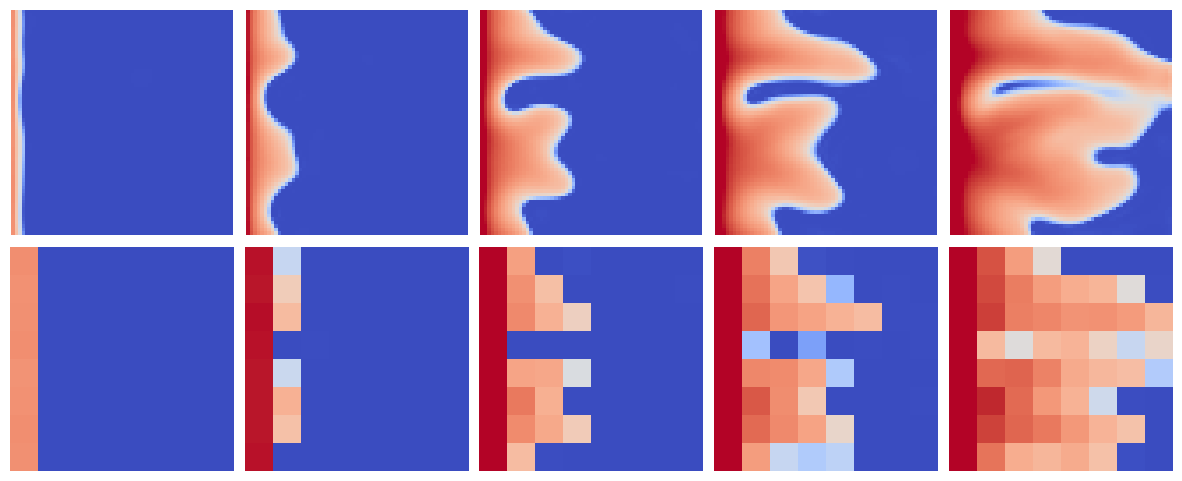

In [15]:
sr8_sg = sr8[..., 1]
sr8_sg_ds = downsample(sr8_sg, 8)
print(f"SR8 Sg shape: {sr8_sg.shape}, downsampled SR8 Sg shape: {sr8_sg_ds.shape}")
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    t = ts[i]
    ax[0, i].imshow(sr8_sg[0, t, :, :-1], cmap='coolwarm', vmin=0, vmax=0.5)
    ax[1, i].imshow(sr8_sg_ds[0, t, ...], cmap='coolwarm', vmin=0, vmax=0.5)
    ax[0, i].axis('off')
    ax[1, i].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig('conditional_outputs/figs/Gene_cart_Sg_sr8.pdf', bbox_inches='tight')

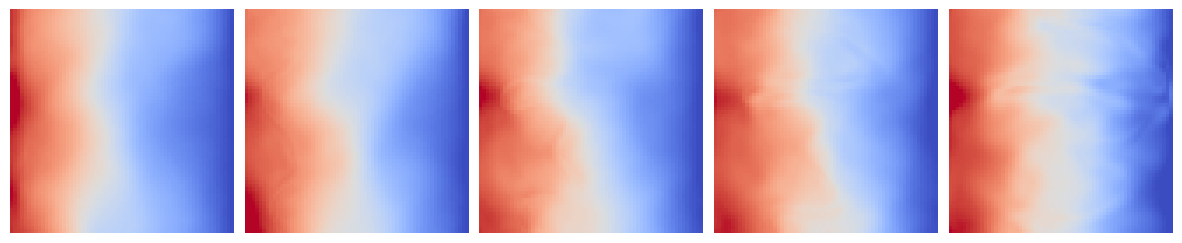

In [388]:
sr8_p = sr8[..., 0]

ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(1, 5, figsize=(15, 6))
for i in range(5):
    t = ts[i]
    ax[i].imshow(sr8_p[0, t, :, :]/1e6, cmap='coolwarm', vmin=12, vmax=15)
    ax[i].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig('conditional_outputs/figs/Gene_cart_P_sr8.pdf', bbox_inches='tight')

SR16 K shape: (10, 64, 64)


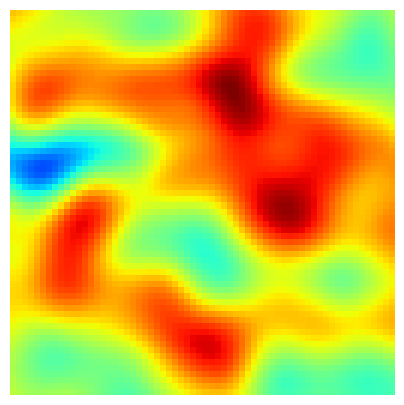

In [7]:
sr16_k = np.mean(sr16[..., -1], axis=1)
print(f"SR16 K shape: {sr16_k.shape}")
plt.figure(figsize=(5, 5))
plt.imshow(sr16_k[9, :, :], cmap='jet', vmin=1.5, vmax=6.5)
plt.axis('off')
plt.savefig('conditional_outputs/figs/Gene_cart_K_sr16.pdf', bbox_inches='tight')

Before downsample shape: torch.Size([10, 64, 64, 64])
After downsample shape: torch.Size([10, 64, 16, 16])
SR16 Sg shape: (10, 64, 64, 64), downsampled SR16 Sg shape: (10, 64, 16, 16)


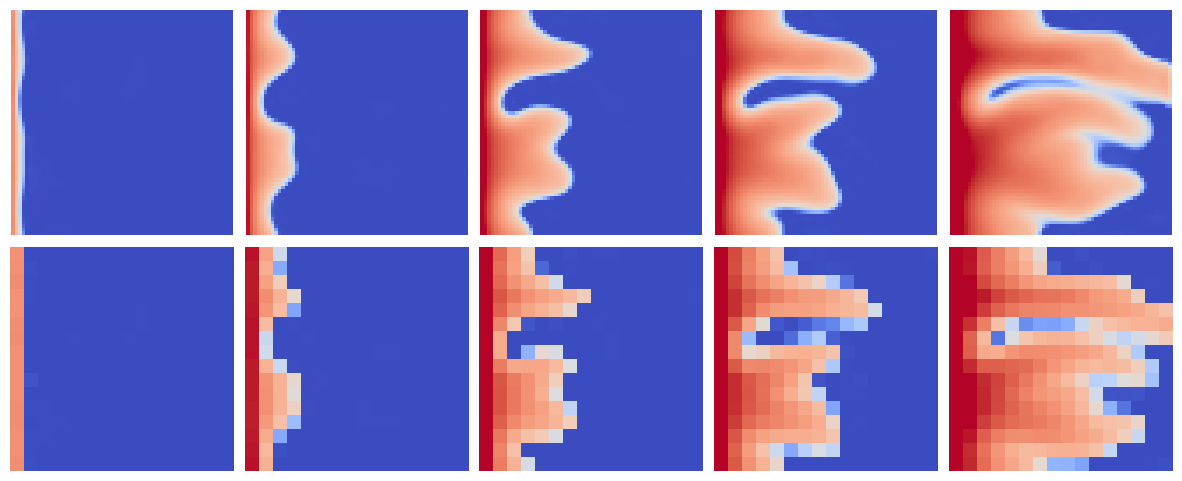

In [16]:
sr16_sg = sr16[..., 1]
sr16_sg_ds = downsample(sr16_sg, 16)
print(f"SR16 Sg shape: {sr16_sg.shape}, downsampled SR16 Sg shape: {sr16_sg_ds.shape}")
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    t = ts[i]
    ax[0, i].imshow(sr16_sg[9, t, :, :-1], cmap='coolwarm', vmin=0, vmax=0.5)
    ax[1, i].imshow(sr16_sg_ds[9, t, ...], cmap='coolwarm', vmin=0, vmax=0.5)
    ax[0, i].axis('off')
    ax[1, i].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig('conditional_outputs/figs/Gene_cart_Sg_sr16.pdf', bbox_inches='tight')

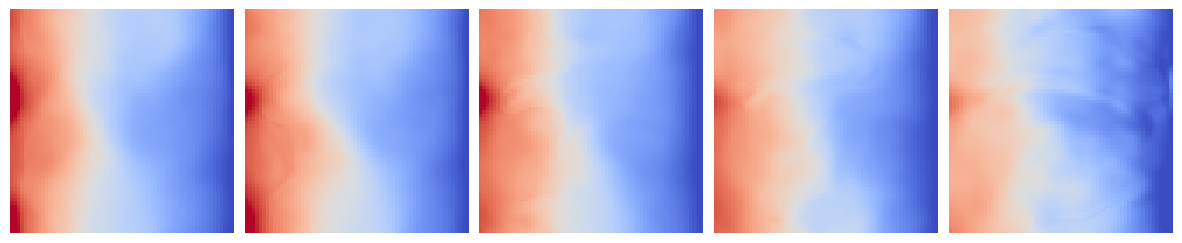

In [389]:
sr16_p = sr16[..., 0]

ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(1, 5, figsize=(15, 6))
for i in range(5):
    t = ts[i]
    ax[i].imshow(sr16_p[9, t, :, :]/1e6, cmap='coolwarm', vmin=12, vmax=15)
    ax[i].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig('conditional_outputs/figs/Gene_cart_P_sr16.pdf', bbox_inches='tight')

SR64 K shape: (10, 64, 64)


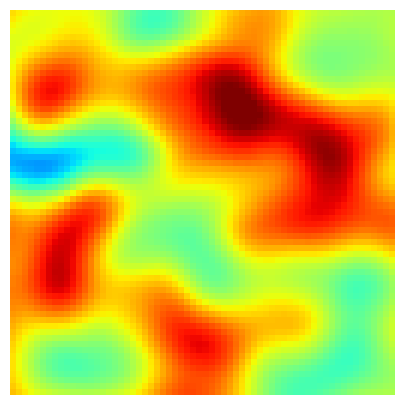

In [25]:
sr64_k = np.mean(sr64[..., -1], axis=1)
print(f"SR64 K shape: {sr64_k.shape}")
plt.figure(figsize=(5, 5))
plt.imshow(sr64_k[6, :, :], cmap='jet', vmin=1.5, vmax=6.5)
plt.axis('off')
plt.savefig('conditional_outputs/figs/Gene_cart_K_sr64.pdf', bbox_inches='tight')

Before downsample shape: torch.Size([10, 64, 64, 64])
After downsample shape: torch.Size([10, 64, 64, 64])


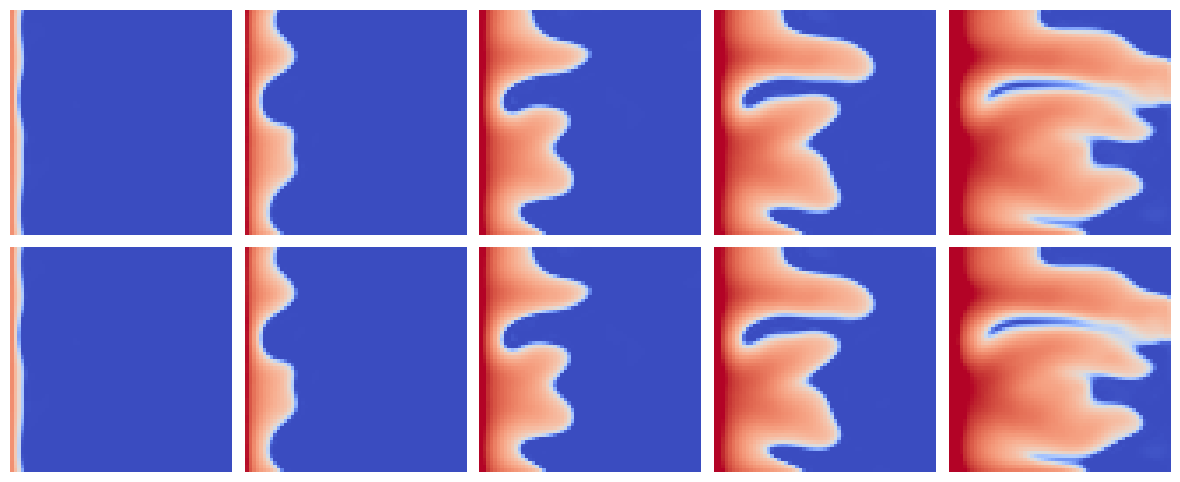

In [28]:
sr64_sg = sr64[..., 1]
sr64_sg_ds = downsample(sr64_sg, 64)
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    t = ts[i]
    ax[0, i].imshow(sr64_sg[6, t, :, :-1], cmap='coolwarm', vmin=0, vmax=0.5)
    ax[1, i].imshow(sr64_sg_ds[6, t, :, :-1], cmap='coolwarm', vmin=0, vmax=0.5)
    ax[0, i].axis('off')
    ax[1, i].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig('conditional_outputs/figs/Gene_cart_Sg_sr64.pdf', bbox_inches='tight')

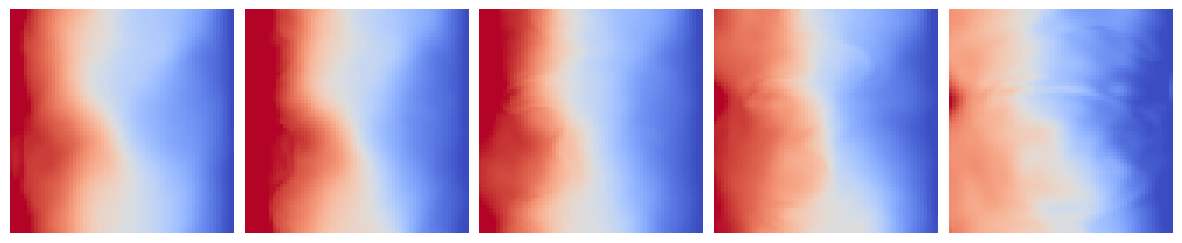

In [29]:
sr64_p = sr64[..., 0]

ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(1, 5, figsize=(15, 6))
for i in range(5):
    t = ts[i]
    ax[i].imshow(sr64_p[0, t, :, :]/1e6, cmap='coolwarm', vmin=12, vmax=15)
    ax[i].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig('conditional_outputs/figs/Gene_cart_P_sr64.pdf', bbox_inches='tight')

*Plot colorbars separately*

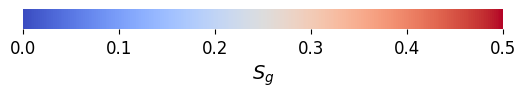

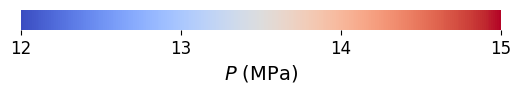

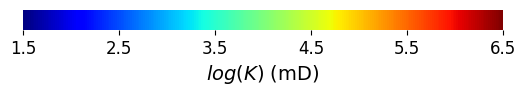

In [400]:
import matplotlib.colorbar as colorbar
import matplotlib.colors as colors

cmap = plt.get_cmap("coolwarm")
norm = colors.Normalize(vmin=0, vmax=0.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig = plt.figure(figsize=(6, 2))
cbar_ax = fig.add_axes([0.2, 0.5, 0.8, 0.1])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("$S_g$", fontsize=14)
cbar.ax.tick_params(labelsize=12)
cbar.outline.set_visible(False)

plt.savefig("conditional_outputs/figs/colorbar_Sg.pdf", bbox_inches='tight')
plt.show()

# -------------------------------------------

cmap = plt.get_cmap("coolwarm")
norm = colors.Normalize(vmin=12, vmax=15)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig = plt.figure(figsize=(6, 2))
cbar_ax = fig.add_axes([0.2, 0.5, 0.8, 0.1])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("$P$ (MPa)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
cbar.set_ticks([12, 13, 14, 15])
cbar.outline.set_visible(False)

plt.savefig("conditional_outputs/figs/colorbar_P.pdf", bbox_inches='tight')
plt.show()

# -------------------------------------------

cmap = plt.get_cmap("jet")
norm = colors.Normalize(vmin=1.5, vmax=6.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig = plt.figure(figsize=(6, 2))
cbar_ax = fig.add_axes([0.2, 0.5, 0.8, 0.1])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("$log(K)$ (mD)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
cbar.set_ticks([1.5, 2.5, 3.5, 4.5, 5.5, 6.5])
cbar.outline.set_visible(False)

plt.savefig("conditional_outputs/figs/colorbar_K.pdf", bbox_inches='tight')
plt.show()

*plot statistical*

In [20]:
from skimage.metrics import structural_similarity as ssim
ref_k = ref[0, :, :, -1]
print(f"Reference K shape: {ref_k.shape}, SR4 K shape: {sr4_k.shape}, SR8 K shape: {sr8_k.shape}, SR16 K shape: {sr16_k.shape}")

Reference K shape: (64, 64), SR4 K shape: (10, 64, 64), SR8 K shape: (10, 64, 64), SR16 K shape: (10, 64, 64)


In [21]:
def compute_ssim(ref, gen):
    ssim_values = []
    for i in range(gen.shape[0]):
        ssim_value = ssim(ref, gen[i, :, :], data_range=gen[i, :, :].max() - gen[i, :, :].min())
        ssim_values.append(ssim_value)
    return np.array(ssim_values)

In [305]:
sr4_k_ssim = compute_ssim(ref_k, sr4_k)
sr8_k_ssim = compute_ssim(ref_k, sr8_k)
sr16_k_ssim = compute_ssim(ref_k, sr16_k)
print(f"SR4 K SSIM: {sr4_k_ssim}, \nSR8 K SSIM: {sr8_k_ssim}, \nSR16 K SSIM: {sr16_k_ssim}")

SR4 K SSIM: [0.19401002 0.31534705 0.22791163 0.29727367 0.25212027 0.34504898
 0.32837516 0.36046009 0.25809255 0.21446125], 
SR8 K SSIM: [0.5936494  0.5821021  0.55480961 0.49724701 0.57947699 0.57808239
 0.5638979  0.52986571 0.56730885 0.58412021], 
SR16 K SSIM: [0.60251801 0.59093278 0.60964483 0.62155803 0.6118145  0.62350572
 0.61145446 0.62343845 0.63200265 0.62812577]


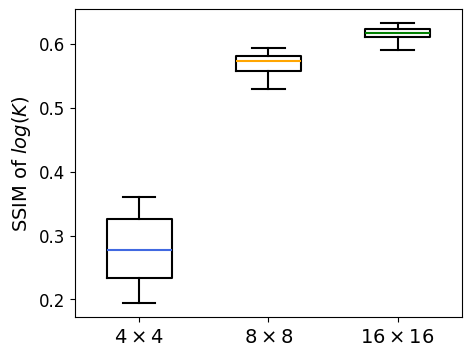

In [378]:
plt.figure(figsize=(5, 4))
bp = plt.boxplot([sr4_k_ssim, sr8_k_ssim, sr16_k_ssim], positions=[1, 2, 3], widths=0.5, showfliers=False, patch_artist=False,)

colors = ['royalblue', 'orange', 'green']

for i, median in enumerate(bp['medians']):
    median.set(color=colors[i], linewidth=1.5)
for patch in bp['boxes']:
    patch.set_linewidth(1.5)
for whisker in bp['whiskers']:
    whisker.set(color='k', linewidth=1.5)
for cap in bp['caps']:
    cap.set(color='k', linewidth=1.5)

plt.xticks([1, 2, 3], [r'$4\times4$', r'$8\times8$', r'$16\times16$'], fontsize=14)
plt.yticks(fontsize=12)
plt.ylabel('SSIM of $log(K)$', fontsize=14)

plt.savefig('conditional_outputs/figs/SSIM_Cart_SR_K.pdf', bbox_inches='tight')
plt.show()

In [365]:
sr4_k_hist = sr4_k[0]
sr8_k_hist = sr8_k[0]
sr16_k_hist = sr16_k[9]
print(f"Ref K shape: {ref_k.shape}, SR4 K shape: {sr4_k_hist.shape}, SR8 K shape: {sr8_k_hist.shape}, SR16 K shape: {sr16_k_hist.shape}")

Ref K shape: (64, 64), SR4 K shape: (64, 64), SR8 K shape: (64, 64), SR16 K shape: (64, 64)


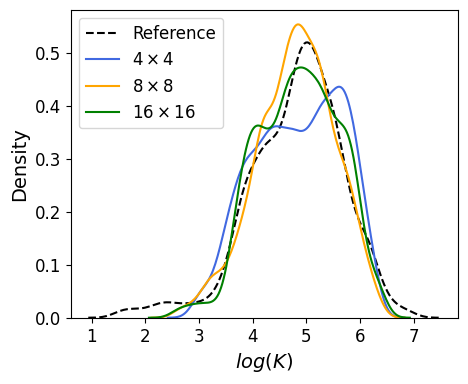

In [377]:
plt.figure(figsize=(5, 4))
import seaborn as sns
sns.kdeplot(ref_k.flatten(), color='black', label='Reference', linewidth=1.5, fill=False, ls='--')
sns.kdeplot(sr4_k_hist.flatten(), color='royalblue', label=r'$4\times4$', linewidth=1.5, fill=False)
sns.kdeplot(sr8_k_hist.flatten(), color='orange', label=r'$8\times8$', linewidth=1.5, fill=False)
sns.kdeplot(sr16_k_hist.flatten(), color='green', label=r'$16\times16$', linewidth=1.5, fill=False)
# plt.xlim(1.5, 6.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('$log(K)$', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(fontsize=12)
plt.savefig('conditional_outputs/figs/Hist_Cart_SR_K.pdf', bbox_inches='tight')
plt.show()

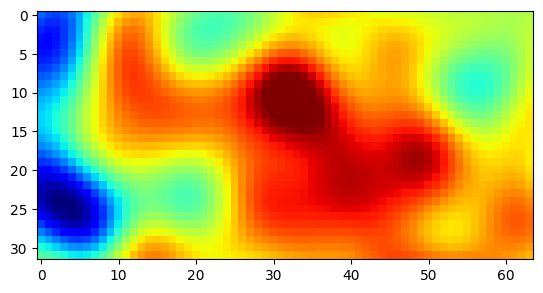

In [51]:
plt.imshow(ref_k[:32], cmap='jet', vmin=1.5, vmax=6.5)

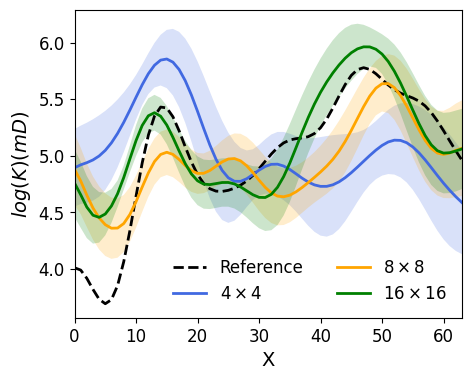

In [52]:
row_idx = 32
ref_k_line = ref[0, row_idx, :, -1]
sr4_k_line = sr4_k[:, row_idx, :]
sr8_k_line = sr8_k[:, row_idx, :]
sr16_k_line = sr16_k[:, row_idx, :]

def compute_mean_std(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    return mean, std
def plot_line_and_fill(data, color, label):
    mean, std = compute_mean_std(data)
    plt.plot(range(64), mean, color=color, linewidth=2, ls='-', label=label)
    plt.fill_between(range(64), mean - std, mean + std, color=color, alpha=0.2, edgecolor='none')

plt.figure(figsize=(5, 4))
plt.plot(ref_k_line, color='black', label='Reference', linewidth=2, ls='--')
plot_line_and_fill(sr4_k_line, 'royalblue', r'$4\times4$')
plot_line_and_fill(sr8_k_line, 'orange', r'$8\times8$')
plot_line_and_fill(sr16_k_line, 'green', r'$16\times16$')

plt.xlim(0, 63)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('X', fontsize=14)
plt.ylabel('$log(K) (mD)$', fontsize=14)
plt.legend(fontsize=12, frameon=False, ncols=2)
plt.savefig('conditional_outputs/figs/Line_spatial_K.pdf', bbox_inches='tight')
plt.show()

In [22]:
ref_sg = ref[:, :, :, 1]
print(f"Reference Sg shape: {ref_sg.shape}, SR4 Sg shape: {sr4_sg.shape}, SR8 Sg shape: {sr8_sg.shape}, SR16 Sg shape: {sr16_sg.shape}")

Reference Sg shape: (64, 64, 64), SR4 Sg shape: (10, 64, 64, 64), SR8 Sg shape: (10, 64, 64, 64), SR16 Sg shape: (10, 64, 64, 64)


In [23]:
def compute_temporal_ssim(ref, gen):
    ssim_values = []
    for i in range(gen.shape[0]):
        ssim_t_values = []
        for t in range(gen.shape[1]):
            ssim_value = ssim(ref_sg[t, :, :], gen[i, t, :, :], data_range=gen[i, t, :, :].max() - gen[i, t, :, :].min())
            ssim_t_values.append(ssim_value)
        ssim_values.append(np.array(ssim_t_values))
    return np.array(ssim_values)

In [24]:
sr4_sg_ssim = compute_temporal_ssim(ref_sg, sr4_sg)
sr8_sg_ssim = compute_temporal_ssim(ref_sg, sr8_sg)
sr16_sg_ssim = compute_temporal_ssim(ref_sg, sr16_sg)
print(f"SR4 Sg SSIM: {sr4_sg_ssim.shape}, \nSR8 Sg SSIM: {sr8_sg_ssim.shape}, \nSR16 Sg SSIM: {sr16_sg_ssim.shape}")

sr4_sg_ssim_mean = np.mean(sr4_sg_ssim, axis=0)
sr8_sg_ssim_mean = np.mean(sr8_sg_ssim, axis=0)
sr16_sg_ssim_mean = np.mean(sr16_sg_ssim, axis=0)

sr4_sg_ssim_std = np.std(sr4_sg_ssim, axis=0)
sr8_sg_ssim_std = np.std(sr8_sg_ssim, axis=0)
sr16_sg_ssim_std = np.std(sr16_sg_ssim, axis=0)

SR4 Sg SSIM: (10, 64), 
SR8 Sg SSIM: (10, 64), 
SR16 Sg SSIM: (10, 64)


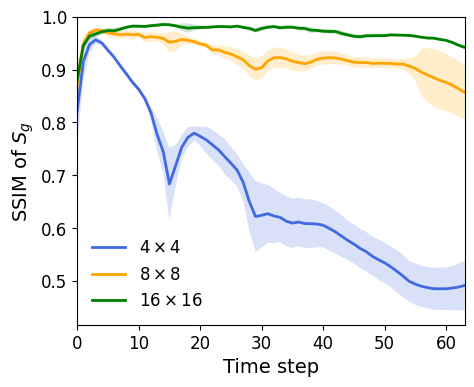

In [36]:
plt.figure(figsize=(5, 4))
plt.plot(range(64), sr4_sg_ssim_mean, color='royalblue', linewidth=2, label=r'$4\times4$')
plt.fill_between(range(64), sr4_sg_ssim_mean - sr4_sg_ssim_std, sr4_sg_ssim_mean + sr4_sg_ssim_std, color='royalblue', alpha=0.2, edgecolor='none')
plt.plot(range(64), sr8_sg_ssim_mean, color='orange', linewidth=2, label=r'$8\times8$')
plt.fill_between(range(64), sr8_sg_ssim_mean - sr8_sg_ssim_std, sr8_sg_ssim_mean + sr8_sg_ssim_std, color='orange', alpha=0.2, edgecolor='none')
plt.plot(range(64), sr16_sg_ssim_mean, color='green', linewidth=2, label=r'$16\times16$')
plt.fill_between(range(64), sr16_sg_ssim_mean - sr16_sg_ssim_std, sr16_sg_ssim_mean + sr16_sg_ssim_std, color='green', alpha=0.2, edgecolor='none')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Time step', fontsize=14)
plt.ylabel('SSIM of $S_g$', fontsize=14)
plt.legend(fontsize=12, frameon=False)
plt.xlim(0, 63)
plt.ylim(top=1)
plt.savefig('conditional_outputs/figs/SSIM_Cart_SR_Sg.pdf', bbox_inches='tight')
plt.show()

## **Condition**: partial obervations of $S_g$ and $P$ (monitoring wells)

### Operator and Sampler

In [94]:
operator =  get_operator(name='cartesian_sparse_measurement',
                        device=device,
                        ckpt_path='/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/checkpoint_14996.pt',
                        norm_record_path='/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/normalizer_params.pt',
                        simdata_path='/ehome/zhao/nf/CoNFiLD/Dataset/Cartesian_all3_small.npy',
                        simdata_idx=1998,
                        num_probed=20,
                        )

query_pts = operator.query_points
np.save('conditional_outputs/npys/query_pts_cart_sparse20.npy', np.array(query_pts))

noiser = get_noise(sigma=0.0, name='gaussian')

cond_method = get_conditioning_method(operator=operator, noiser=noiser, name='ps_adam', scale=1e-2)    # \lambda=1
measurement_cond_fn = partial(cond_method.conditioning)

sampler = create_sampler(sampler='ddpm',
                        steps=1000,
                        noise_schedule="cosine",
                        model_mean_type="epsilon",
                        model_var_type="learned_range",
                        dynamic_threshold=False,
                        clip_denoised=True,
                        rescale_timesteps=False,
                        timestep_respacing="")

sample_fn = partial(sampler.p_sample_loop, model=u_net_model, measurement_cond_fn=measurement_cond_fn)


/ehome/zhao/nf/CoNFiLD/ConditionalDiffusionGeneration/inference_scripts/Case4/random_sensor/../../../../ConditionalDiffusionGeneration/src/guided_diffusion/measurements.py:492: UserWarning: Randomly generated 20 points for measurement, please check the results.
  warnings.warn(f"Randomly generated {num_probed} points for measurement, please check the results.")


Simulation data loaded, with shape (64, 64, 64, 3)


In [95]:
print(operator.query_points)
np.save('conditional_outputs/npys/query_pts_cart_sparse20.npy', np.array(operator.query_points))

[(41, 1), (6, 4), (15, 53), (44, 57), (31, 33), (36, 50), (10, 35), (26, 18), (23, 62), (47, 38), (51, 8), (37, 9), (57, 24), (1, 43), (21, 19), (16, 25), (55, 46), (61, 49), (5, 14), (33, 29)]


### Generation

In [33]:
no_of_samples = 10
time_length = 64
latent_size = 256

x_start = torch.randn(no_of_samples, 1, time_length, latent_size, device=device)
measurement_ref = operator.sparse_cartesian_measurement()
samples = [sample_fn(x_start=x_start[i:i+1], measurement=measurement_ref, record=False, save_root=None) for i in range(x_start.shape[0])]

Simulation data normed, with min -1.0, max 0.9795703887939453
Measurement shape: torch.Size([64, 5, 2])


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

### Save generated latents

In [34]:
gen_latents = torch.cat(samples)
gen_latents = operator._unnorm(gen_latents)
gen_latents = gen_latents[:,0]
print(f"Generated latents shape: {gen_latents.shape}")
torch.save(gen_latents, 'conditional_outputs/pts/generated_latents_Cart5Sparse.pt')

Generated latents shape: torch.Size([10, 64, 256])


### Deocding by CNF

In [35]:
from ConditionalNeuralField.cnf.nf_networks import SIRENAutodecoder_mdf_film
nf = SIRENAutodecoder_mdf_film(omega_0=5,
                                in_coord_features=2,
                                in_latent_features=256,
                                out_features=3,
                                num_hidden_layers=5,
                                hidden_features=128)
ckpt = torch.load("/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/checkpoint_14996.pt")
nf.load_state_dict(ckpt['model_state_dict'])
nf.eval()
nf.to(device)
del ckpt
print('nf loaded')

nf loaded


In [36]:
whole_coords = operator._gene_cartesian_coord()
whole_coords_in = whole_coords.unsqueeze(0).to(device)
gen_latents_in = rearrange(gen_latents, 'b t l -> (b t) 1 1 l' )
gen_latents_in = gen_latents_in.to(device)
with torch.no_grad():
    nf_out_gene = nf(whole_coords_in, gen_latents_in)
nf_out_gene = operator._unnorm_cnf(nf_out_gene)
nf_out_gene = nf_out_gene.reshape(no_of_samples, time_length, 64, 64, 3)
print(f"CNF output shape: {nf_out_gene.shape}")
torch.save(nf_out_gene, 'conditional_outputs/pts/CNF_out_Cart5Sparse.pt')

CNF output shape: torch.Size([10, 64, 64, 64, 3])


### ***Load CNF and plot***

In [43]:
sparse1 = torch.load('conditional_outputs/pts/CNF_out_Cart1Sparse.pt', map_location='cpu').detach().numpy()
sparse5 = torch.load('conditional_outputs/pts/CNF_out_Cart5Sparse.pt', map_location='cpu').detach().numpy()
sparse20 = torch.load('conditional_outputs/pts/CNF_out_Cart20Sparse.pt', map_location='cpu').detach().numpy()
ref = operator.simdata
print(f"Reference shape: {ref.shape}, CNF output shape: {sparse5.shape}")

Reference shape: (64, 64, 64, 3), CNF output shape: (10, 64, 64, 64, 3)


*plot maps*

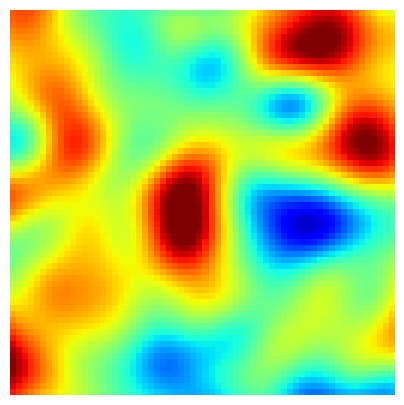

In [44]:
plt.figure(figsize=(5, 5))
plt.imshow(ref[0, :, :, -1], cmap='jet', vmin=1.5, vmax=6.5)
plt.axis('off')
plt.savefig('conditional_outputs/figs_cart_sparse/Ref_cart_K_sparse_case.pdf', bbox_inches='tight')

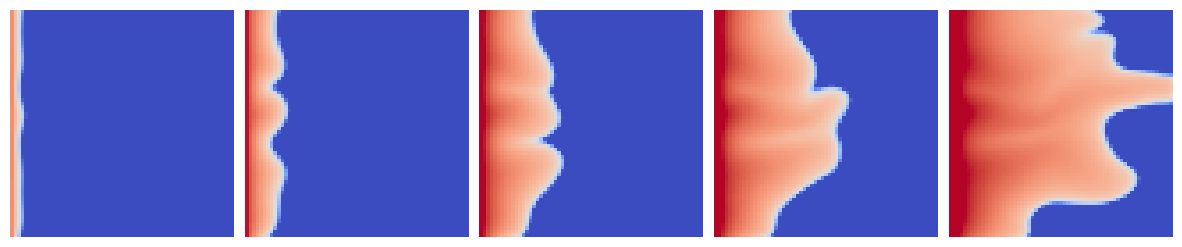

In [45]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(ref[t, :, :-1, 1], cmap='coolwarm', vmin=0, vmax=0.5)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Ref_cart_Sg_sparse_case.pdf', bbox_inches='tight')

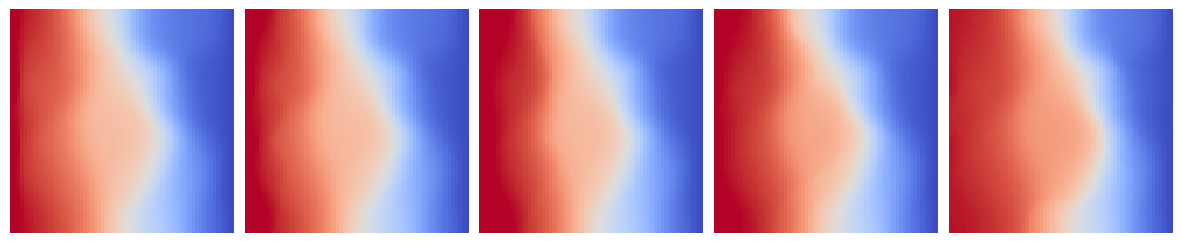

In [46]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(ref[t, :, :, 0]/1e6, cmap='coolwarm', vmin=12, vmax=16)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Ref_cart_P_sparse_case.pdf', bbox_inches='tight')

Sparse1 K shape: (10, 64, 64)


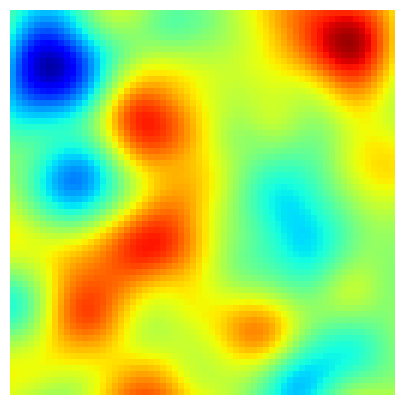

In [47]:
sparse1_k = np.mean(sparse1[..., -1], axis=1)
print(f"Sparse1 K shape: {sparse1_k.shape}")
plt.figure(figsize=(5, 5))
plt.imshow(sparse1_k[0, :, :], cmap='jet', vmin=1.5, vmax=6.5)
plt.axis('off')
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_K_sparse1.pdf', bbox_inches='tight')

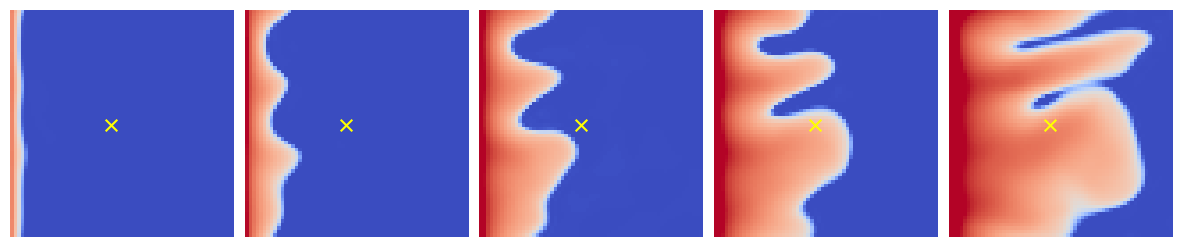

In [104]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
pts = [(32, 28)]
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse1[0, t, :, :-1, 1], cmap='coolwarm', vmin=0, vmax=0.5)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_Sg_sparse1.pdf', bbox_inches='tight')

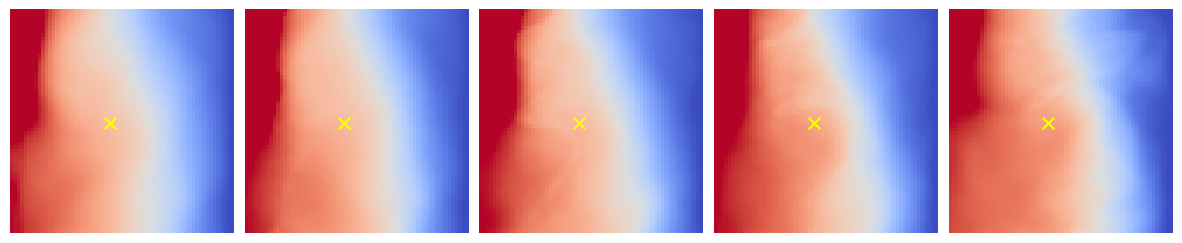

In [103]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
pts = [(32, 28)]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse1[0, t, :, :, 0]/1e6, cmap='coolwarm', vmin=12, vmax=16)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_P_sparse1.pdf', bbox_inches='tight')

Sparse5 K shape: (10, 64, 64)


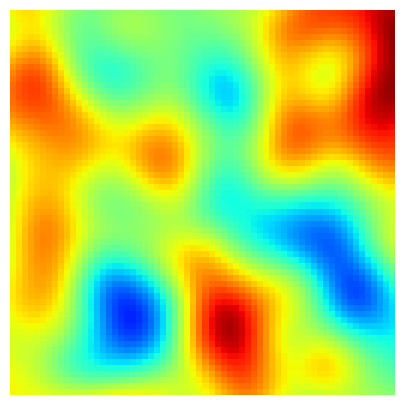

In [69]:
sparse5_k = np.mean(sparse5[..., -1], axis=1)
print(f"Sparse5 K shape: {sparse5_k.shape}")
plt.figure(figsize=(5, 5))
plt.imshow(sparse5_k[0, :, :], cmap='jet', vmin=1.5, vmax=6.5)
plt.axis('off')
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_K_sparse5.pdf', bbox_inches='tight')

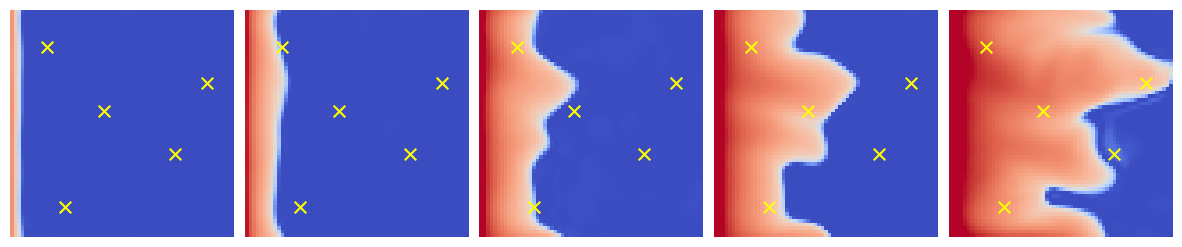

In [102]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
pts = [(10, 10), (20, 55), (28, 26), (40, 46), (55, 15)]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse5[0, t, :, :-1, 1], cmap='coolwarm', vmin=0, vmax=0.5)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_Sg_sparse5.pdf', bbox_inches='tight')

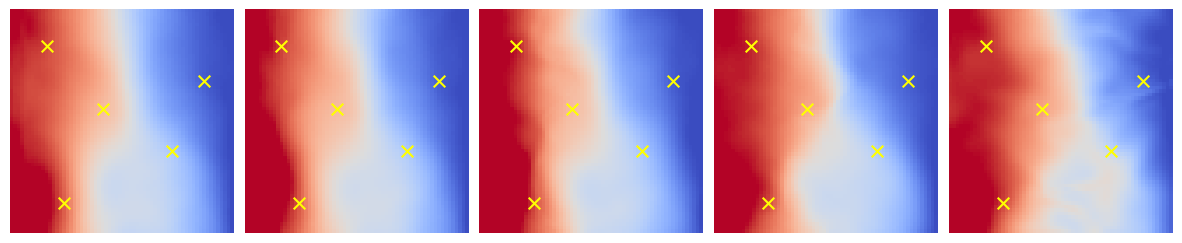

In [101]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
pts = [(10, 10), (20, 55), (28, 26), (40, 46), (55, 15)]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse5[0, t, :, :, 0]/1e6, cmap='coolwarm', vmin=12, vmax=16)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_P_sparse5.pdf', bbox_inches='tight')

Sparse20 K shape: (10, 64, 64)


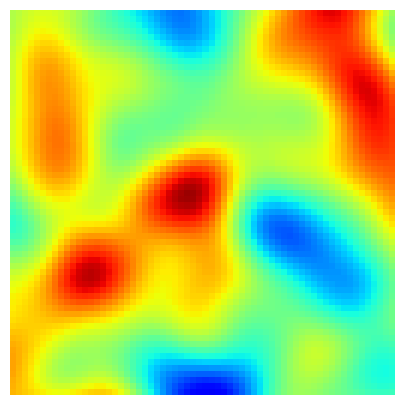

In [302]:
sparse20_k = np.mean(sparse20[..., -1], axis=1)
print(f"Sparse20 K shape: {sparse20_k.shape}")
plt.figure(figsize=(5, 5))
plt.imshow(sparse20_k[1, :, :], cmap='jet', vmin=1.5, vmax=6.5)
plt.axis('off')
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_K_sparse20.pdf', bbox_inches='tight')

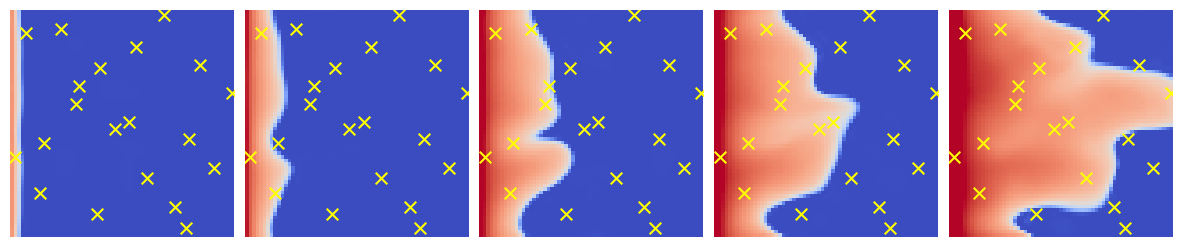

In [98]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
pts = np.load('conditional_outputs/npys/query_pts_cart_sparse20.npy')
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse20[1, t, :, :-1, 1], cmap='coolwarm', vmin=0, vmax=0.5)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_Sg_sparse20.pdf', bbox_inches='tight')

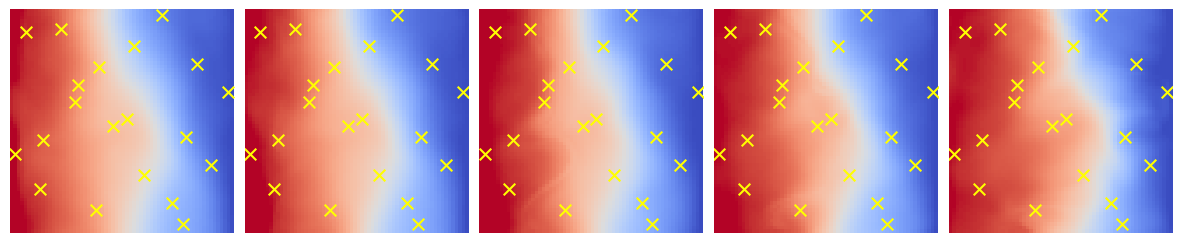

In [100]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
pts = np.load('conditional_outputs/npys/query_pts_cart_sparse20.npy')
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse20[1, t, :, :, 0]/1e6, cmap='coolwarm', vmin=12, vmax=16)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_P_sparse20.pdf', bbox_inches='tight')

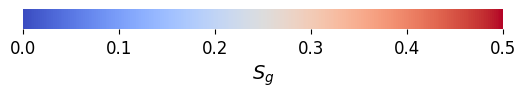

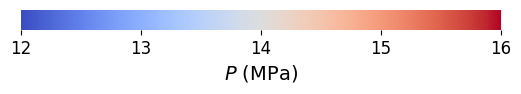

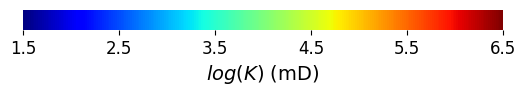

In [105]:
import matplotlib.colorbar as colorbar
import matplotlib.colors as colors

cmap = plt.get_cmap("coolwarm")
norm = colors.Normalize(vmin=0, vmax=0.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig = plt.figure(figsize=(6, 2))
cbar_ax = fig.add_axes([0.2, 0.5, 0.8, 0.1])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("$S_g$", fontsize=14)
cbar.ax.tick_params(labelsize=12)
cbar.outline.set_visible(False)

plt.savefig("conditional_outputs/figs_cart_sparse/colorbar_Sg.pdf", bbox_inches='tight')
plt.show()

# -------------------------------------------

cmap = plt.get_cmap("coolwarm")
norm = colors.Normalize(vmin=12, vmax=16)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig = plt.figure(figsize=(6, 2))
cbar_ax = fig.add_axes([0.2, 0.5, 0.8, 0.1])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("$P$ (MPa)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
cbar.set_ticks([12, 13, 14, 15, 16])
cbar.outline.set_visible(False)

plt.savefig("conditional_outputs/figs_cart_sparse/colorbar_P.pdf", bbox_inches='tight')
plt.show()

# -------------------------------------------

cmap = plt.get_cmap("jet")
norm = colors.Normalize(vmin=1.5, vmax=6.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig = plt.figure(figsize=(6, 2))
cbar_ax = fig.add_axes([0.2, 0.5, 0.8, 0.1])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("$log(K)$ (mD)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
cbar.set_ticks([1.5, 2.5, 3.5, 4.5, 5.5, 6.5])
cbar.outline.set_visible(False)

plt.savefig("conditional_outputs/figs_cart_sparse/colorbar_K.pdf", bbox_inches='tight')
plt.show()

## **Condition**: partial obervations of $S_g$, $P$, and $K$ (monitoring wells and well logs)

### Operator and Sampler

In [22]:
operator =  get_operator(name='cartesian_sparse_measurement_all',
                        device=device,
                        ckpt_path='/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/checkpoint_14996.pt',
                        norm_record_path='/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/normalizer_params.pt',
                        simdata_path='/ehome/zhao/nf/CoNFiLD/Dataset/Cartesian_all3_small.npy',
                        simdata_idx=1998,
                        num_probed=5,
                        )

query_pts = operator.query_points
np.save('conditional_outputs/npys/query_pts_cart_sparse20.npy', np.array(query_pts))

noiser = get_noise(sigma=0.0, name='gaussian')

cond_method = get_conditioning_method(operator=operator, noiser=noiser, name='ps_adam', scale=1e-2)    # \lambda=1
measurement_cond_fn = partial(cond_method.conditioning)

sampler = create_sampler(sampler='ddpm',
                        steps=1000,
                        noise_schedule="cosine",
                        model_mean_type="epsilon",
                        model_var_type="learned_range",
                        dynamic_threshold=False,
                        clip_denoised=True,
                        rescale_timesteps=False,
                        timestep_respacing="")

sample_fn = partial(sampler.p_sample_loop, model=u_net_model, measurement_cond_fn=measurement_cond_fn)

Simulation data loaded, with shape (64, 64, 64, 3)


In [23]:
print(operator.query_points)

[(10, 10), (20, 55), (28, 26), (40, 46), (55, 15)]


### Generation

In [24]:
no_of_samples = 10
time_length = 64
latent_size = 256

x_start = torch.randn(no_of_samples, 1, time_length, latent_size, device=device)
measurement_ref = operator.sparse_cartesian_measurement()
samples = [sample_fn(x_start=x_start[i:i+1], measurement=measurement_ref, record=False, save_root=None) for i in range(x_start.shape[0])]

Simulation data normed, with min -1.0, max 0.9795703887939453
Measurement shape: torch.Size([64, 5, 3])


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

### Save generated latents

In [25]:
gen_latents = torch.cat(samples)
gen_latents = operator._unnorm(gen_latents)
gen_latents = gen_latents[:,0]
print(f"Generated latents shape: {gen_latents.shape}")
torch.save(gen_latents, 'conditional_outputs/pts/generated_latents_Cart5Sparse_All.pt')

Generated latents shape: torch.Size([10, 64, 256])


### Decoding by CNF

In [26]:
from ConditionalNeuralField.cnf.nf_networks import SIRENAutodecoder_mdf_film
nf = SIRENAutodecoder_mdf_film(omega_0=5,
                                in_coord_features=2,
                                in_latent_features=256,
                                out_features=3,
                                num_hidden_layers=5,
                                hidden_features=128)
ckpt = torch.load("/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/checkpoint_14996.pt")
nf.load_state_dict(ckpt['model_state_dict'])
nf.eval()
nf.to(device)
del ckpt
print('nf loaded')

nf loaded


In [27]:
whole_coords = operator._gene_cartesian_coord()
whole_coords_in = whole_coords.unsqueeze(0).to(device)
gen_latents_in = rearrange(gen_latents, 'b t l -> (b t) 1 1 l' )
gen_latents_in = gen_latents_in.to(device)
with torch.no_grad():
    nf_out_gene = nf(whole_coords_in, gen_latents_in)
nf_out_gene = operator._unnorm_cnf(nf_out_gene)
nf_out_gene = nf_out_gene.reshape(no_of_samples, time_length, 64, 64, 3)
print(f"CNF output shape: {nf_out_gene.shape}")
torch.save(nf_out_gene, 'conditional_outputs/pts/CNF_out_Cart5Sparse_All.pt')

CNF output shape: torch.Size([10, 64, 64, 64, 3])


### ***Load CNF and plot***

In [106]:
sparse_all1 = torch.load('conditional_outputs/pts/CNF_out_Cart1Sparse_All.pt', map_location='cpu').detach().numpy()
sparse_all5 = torch.load('conditional_outputs/pts/CNF_out_Cart5Sparse_All.pt', map_location='cpu').detach().numpy()
sparse_all20 = torch.load('conditional_outputs/pts/CNF_out_Cart20Sparse_All.pt', map_location='cpu').detach().numpy()
ref = operator.simdata
print(f"Reference shape: {ref.shape}, CNF output shape: {sparse_all20.shape}")

Reference shape: (64, 64, 64, 3), CNF output shape: (10, 64, 64, 64, 3)


Sparse all1 K shape: (10, 64, 64)


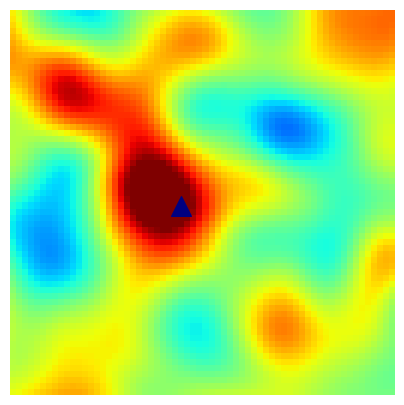

In [314]:
sparse_all1_k = np.mean(sparse_all1[..., -1], axis=1)
print(f"Sparse all1 K shape: {sparse_all1_k.shape}")
pts = [(32, 28)]
plt.figure(figsize=(5, 5))
plt.imshow(sparse_all1_k[0, :, :], cmap='jet', vmin=1.5, vmax=6.5)
for y, x in pts:
    plt.scatter(x, y, color='navy', marker='^', s=200)
plt.axis('off')
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_K_sparse_all1.pdf', bbox_inches='tight')

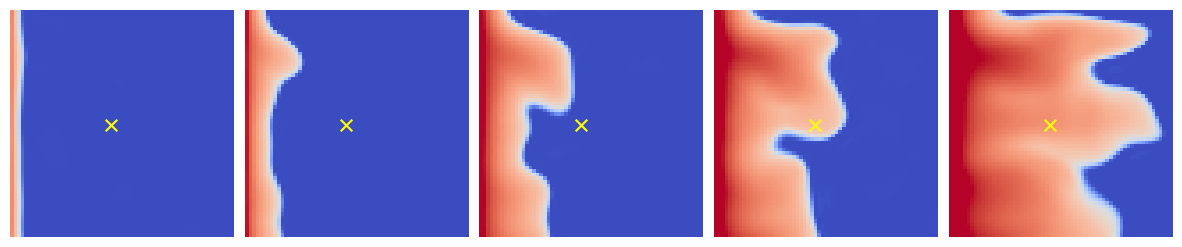

In [128]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
pts = [(32, 28)]
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse_all1[0, t, :, :-1, 1], cmap='coolwarm', vmin=0, vmax=0.5)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_Sg_sparse_all1.pdf', bbox_inches='tight')

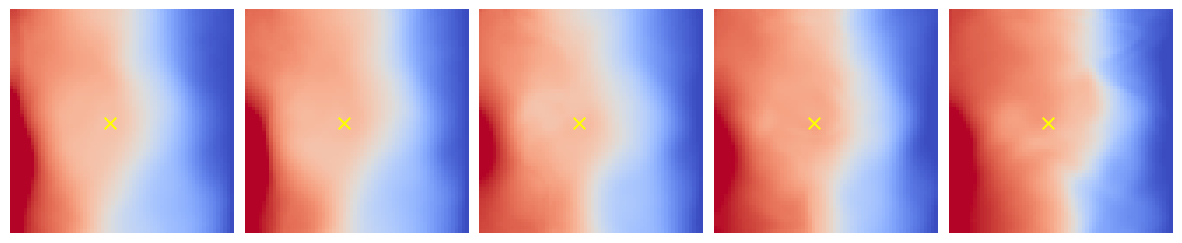

In [129]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
pts = [(32, 28)]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse_all1[0, t, :, :, 0]/1e6, cmap='coolwarm', vmin=12, vmax=16)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_P_sparse_all1.pdf', bbox_inches='tight')

Sparse all5 K shape: (10, 64, 64)


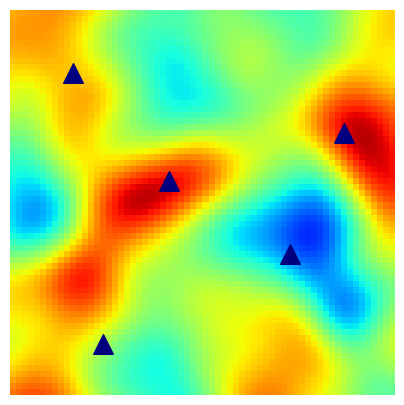

In [313]:
sparse_all5_k = np.mean(sparse_all5[..., -1], axis=1)
print(f"Sparse all5 K shape: {sparse_all5_k.shape}")
pts = [(10, 10), (20, 55), (28, 26), (40, 46), (55, 15)]
plt.figure(figsize=(5, 5))
plt.imshow(sparse_all5_k[7, :, :], cmap='jet', vmin=1.5, vmax=6.5)
for y, x in pts:
    plt.scatter(x, y, color='navy', marker='^', s=200)
plt.axis('off')
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_K_sparse_all5.pdf', bbox_inches='tight')

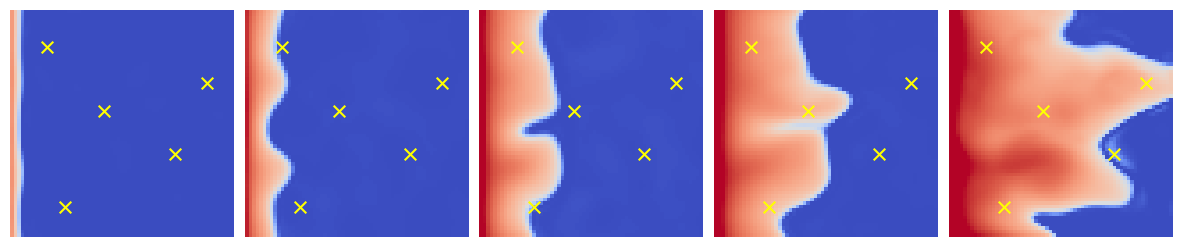

In [142]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
pts = [(10, 10), (20, 55), (28, 26), (40, 46), (55, 15)]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse_all5[7, t, :, :-1, 1], cmap='coolwarm', vmin=0, vmax=0.5)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_Sg_sparse_all5.pdf', bbox_inches='tight')

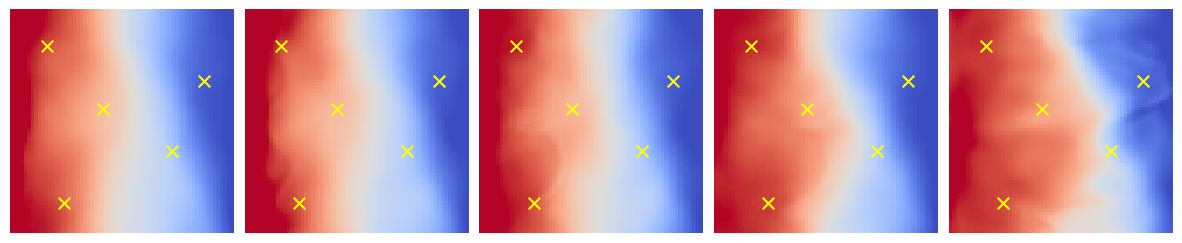

In [144]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
pts = [(10, 10), (20, 55), (28, 26), (40, 46), (55, 15)]
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse_all5[7, t, :, :, 0]/1e6, cmap='coolwarm', vmin=12, vmax=16)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_P_sparse_all5.pdf', bbox_inches='tight')

Sparse_all20 K shape: (10, 64, 64)


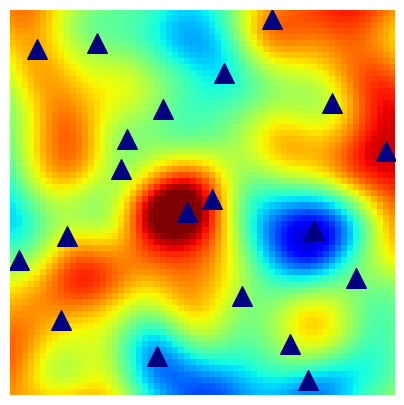

In [312]:
sparse_all20_k = np.mean(sparse_all20[..., -1], axis=1)
print(f"Sparse_all20 K shape: {sparse_all20_k.shape}")
query_pts = np.load('conditional_outputs/npys/query_pts_cart_sparse20.npy')
plt.figure(figsize=(5, 5))
plt.imshow(sparse_all20_k[1, :, :], cmap='jet', vmin=1.5, vmax=6.5)
for y, x in query_pts:
        plt.scatter(x, y, color='navy', marker='^', s=200)
plt.axis('off')
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_K_sparse_all20.pdf', bbox_inches='tight')

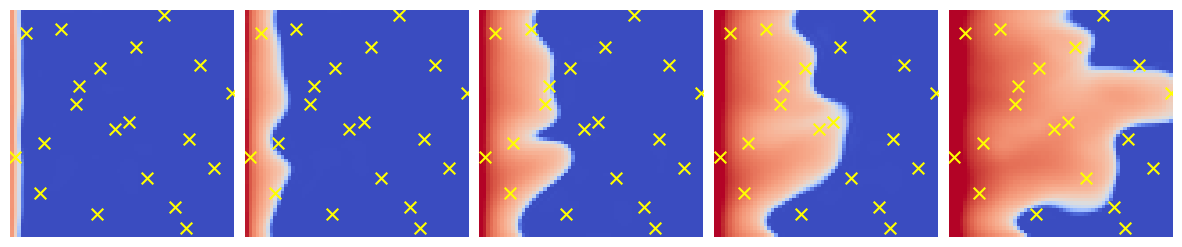

In [152]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
pts = np.load('conditional_outputs/npys/query_pts_cart_sparse20.npy')
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse_all20[1, t, :, :-1, 1], cmap='coolwarm', vmin=0, vmax=0.5)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_Sg_sparse_all20.pdf', bbox_inches='tight')

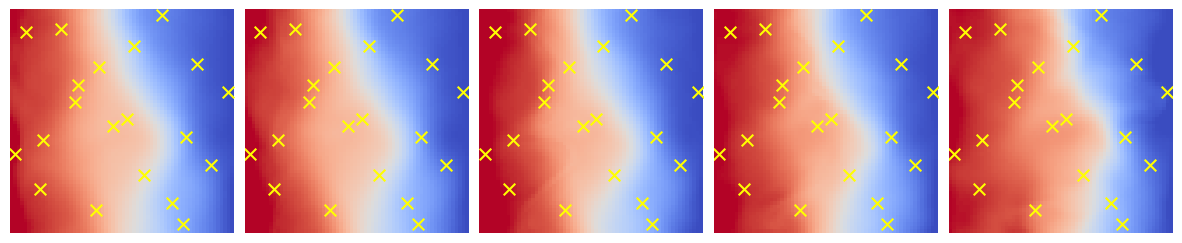

In [153]:
ts = [3, 12, 25, 38, 63]    # 30, 100, 200, 300, 500 days
days = [30, 100, 200, 300, 500]
pts = np.load('conditional_outputs/npys/query_pts_cart_sparse20.npy')
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    t = ts[i]
    im = ax[i].imshow(sparse_all20[1, t, :, :, 0]/1e6, cmap='coolwarm', vmin=12, vmax=16)
    for y, x in pts:
        ax[i].scatter(x, y, color='yellow', marker='x', s=70)
    ax[i].axis('off')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.subplots_adjust(wspace=0.05)
plt.savefig('conditional_outputs/figs_cart_sparse/Gene_cart_P_sparse_all20.pdf', bbox_inches='tight')

## **Statistical analysis..**

**SSIM of K**

In [157]:
from skimage.metrics import structural_similarity as ssim

ref_k = ref[0, ..., -1]
print(f"reference K shape {ref_k.shape}")
print(f"Sparse K: {sparse1_k.shape}, Sparse all K: {sparse_all1_k.shape}")

def compute_ssim(ref, gen):
    ssim_values = []
    for i in range(gen.shape[0]):
        ssim_value = ssim(ref, gen[i, :, :], data_range=gen[i, :, :].max() - gen[i, :, :].min())
        ssim_values.append(ssim_value)
    return np.array(ssim_values)

reference K shape (64, 64)
Sparse K: (10, 64, 64), Sparse all K: (10, 64, 64)


In [158]:
saprse1_k_ssim = compute_ssim(ref_k, sparse1_k)
sparse_all1_k_ssim = compute_ssim(ref_k, sparse_all1_k)
sparse5_k_ssim = compute_ssim(ref_k, sparse5_k)
sparse_all5_k_ssim = compute_ssim(ref_k, sparse_all5_k)
sparse20_k_ssim = compute_ssim(ref_k, sparse20_k)
sparse_all20_k_ssim = compute_ssim(ref_k, sparse_all20_k)

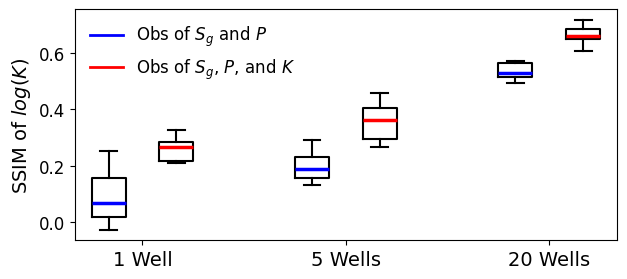

In [310]:
from matplotlib.lines import Line2D

plt.figure(figsize=(7, 3))
data = [saprse1_k_ssim, sparse_all1_k_ssim, sparse5_k_ssim, sparse_all5_k_ssim, sparse20_k_ssim, sparse_all20_k_ssim]
positions = [1, 2, 4, 5, 7, 8]

bp = plt.boxplot(data, positions=positions, widths=0.5, showfliers=False, patch_artist=False,)

colors = ['blue', 'red'] * 3

for i, median in enumerate(bp['medians']):
    median.set(color=colors[i], linewidth=2.5)
for patch in bp['boxes']:
    patch.set_linewidth(1.5)
for whisker in bp['whiskers']:
    whisker.set(color='k', linewidth=1.5)
for cap in bp['caps']:
    cap.set(color='k', linewidth=1.5)

plt.xticks([1.5, 4.5, 7.5], ['1 Well', '5 Wells', '20 Wells'], fontsize=14)
plt.yticks(fontsize=12)
plt.ylabel('SSIM of $log(K)$', fontsize=14)

legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Obs of $S_g$ and $P$'),
    Line2D([0], [0], color='red', lw=2, label='Obs of $S_g$, $P$, and $K$'),
]
plt.legend(handles=legend_elements, loc='upper left', frameon=False, fontsize=12)

plt.savefig('conditional_outputs/figs_cart_sparse/SSIM_Cart_sparse_K.pdf', bbox_inches='tight')
plt.show()

**Comparison of 1 well, 5 wells, and 20 wells' solutions with reference**

In [178]:
def query_well_data(input_data, query_pt, query_dim):
    """
    query_dim = 0: saturation
    query_dim = 1: pressure
    query_dim = 2: permeability
    """
    dims = len(input_data.shape)
    if dims == 4:
        print("Querying reference data")
        return input_data[:, query_pt[0], query_pt[1], query_dim]
    elif dims == 5:
        print("Querying generated data")
        return input_data[:, :, query_pt[0], query_pt[1], query_dim]

In [253]:
qt = (32, 28)
sparse1_sat = query_well_data(sparse1, qt, 1)
sparse_all1_sat = query_well_data(sparse_all1, qt, 1)
sparse1_ref = query_well_data(ref, qt, 1)
print(f"Sparse1 saturation shape: {sparse1_sat.shape}, Sparse all1 saturation shape: {sparse_all1_sat.shape}, \
    Reference saturation shape: {sparse1_ref.shape}")
sparse1_sat_mean = np.mean(sparse1_sat, axis=0)
sparse_all1_sat_mean = np.mean(sparse_all1_sat, axis=0)
sparse1_sat_std = np.std(sparse1_sat, axis=0)
sparse_all1_sat_std = np.std(sparse_all1_sat, axis=0)

qt = (37, 33)
sparse1_sat_unprob = query_well_data(sparse1, qt, 1)
sparse_all1_sat_unprob = query_well_data(sparse_all1, qt, 1)
sparse1_ref_unprob = query_well_data(ref, qt, 1)
sparse1_sat_mean_unprob = np.mean(sparse1_sat_unprob, axis=0)
sparse_all1_sat_mean_unprob = np.mean(sparse_all1_sat_unprob, axis=0)
sparse1_sat_std_unprob = np.std(sparse1_sat_unprob, axis=0)
sparse_all1_sat_std_unprob = np.std(sparse_all1_sat_unprob, axis=0)

Querying generated data
Querying generated data
Querying reference data
Sparse1 saturation shape: (10, 64), Sparse all1 saturation shape: (10, 64),     Reference saturation shape: (64,)
Querying generated data
Querying generated data
Querying reference data


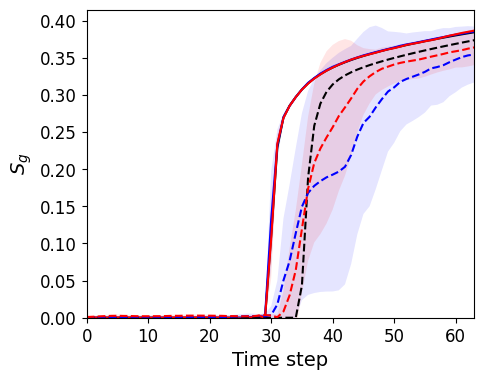

In [308]:
plt.figure(figsize=(5, 4))

# ---------probed point-----------
plt.plot(range(64), sparse1_ref, color='k', linewidth=1.5)

plt.plot(range(64), sparse1_sat_mean, color='blue', linewidth=1.5)
plt.fill_between(range(64), sparse1_sat_mean - sparse1_sat_std, sparse1_sat_mean + sparse1_sat_std, color='blue', alpha=0.1, edgecolor='none')

plt.plot(range(64), sparse_all1_sat_mean, color='red', linewidth=1.5)
plt.fill_between(range(64), sparse_all1_sat_mean - sparse_all1_sat_std, sparse_all1_sat_mean + sparse_all1_sat_std, color='red', alpha=0.1,edgecolor='none')

# ---------unprobed point-----------
plt.plot(range(64), sparse1_ref_unprob, color='k', linewidth=1.5, ls='--')

plt.plot(range(64), sparse1_sat_mean_unprob, color='blue', linewidth=1.5, ls='--')
plt.fill_between(range(64), sparse1_sat_mean_unprob - sparse1_sat_std_unprob, sparse1_sat_mean_unprob + sparse1_sat_std_unprob, color='blue', alpha=0.1, edgecolor='none')

plt.plot(range(64), sparse_all1_sat_mean_unprob, color='red', linewidth=1.5, ls='--')
plt.fill_between(range(64), sparse_all1_sat_mean_unprob - sparse_all1_sat_std_unprob, sparse_all1_sat_mean_unprob + sparse_all1_sat_std_unprob, color='red', alpha=0.1, edgecolor='none')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Time step', fontsize=14)
plt.ylabel('$S_g$', fontsize=14)

plt.xlim(0, 63)
plt.ylim(bottom=0)
plt.savefig('conditional_outputs/figs_cart_sparse/Line_Cart_sparse1.pdf', bbox_inches='tight')
plt.show()

In [251]:
qt = (10, 10)
sparse5_sat = query_well_data(sparse5, qt, 1)
sparse_all5_sat = query_well_data(sparse_all5, qt, 1)
sparse5_ref = query_well_data(ref, qt, 1)
sparse5_sat_mean = np.mean(sparse5_sat, axis=0)
sparse_all5_sat_mean = np.mean(sparse_all5_sat, axis=0)
sparse5_sat_std = np.std(sparse5_sat, axis=0)
sparse_all5_sat_std = np.std(sparse_all5_sat, axis=0)

qt = (15, 15)
sparse5_sat_unprob = query_well_data(sparse5, qt, 1)
sparse_all5_sat_unprob = query_well_data(sparse_all5, qt, 1)
sparse5_ref_unprob = query_well_data(ref, qt, 1)
sparse5_sat_mean_unprob = np.mean(sparse5_sat_unprob, axis=0)
sparse_all5_sat_mean_unprob = np.mean(sparse_all5_sat_unprob, axis=0)
sparse5_sat_std_unprob = np.std(sparse5_sat_unprob, axis=0)
sparse_all5_sat_std_unprob = np.std(sparse_all5_sat_unprob, axis=0)

Querying generated data
Querying generated data
Querying reference data
Querying generated data
Querying generated data
Querying reference data


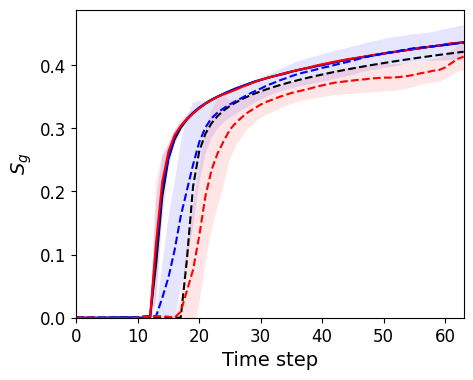

In [307]:
plt.figure(figsize=(5, 4))

# ---------probed point-----------
plt.plot(range(64), sparse5_ref, color='k', linewidth=1.5)

plt.plot(range(64), sparse5_sat_mean, color='blue', linewidth=1.5)
plt.fill_between(range(64), sparse5_sat_mean - sparse5_sat_std, sparse5_sat_mean + sparse5_sat_std, color='blue', alpha=0.1, edgecolor='none')

plt.plot(range(64), sparse_all5_sat_mean, color='red', linewidth=1.5)
plt.fill_between(range(64), sparse_all5_sat_mean - sparse_all5_sat_std, sparse_all5_sat_mean + sparse_all5_sat_std, color='red', alpha=0.1,edgecolor='none')

# ---------unprobed point-----------
plt.plot(range(64), sparse5_ref_unprob, color='k', linewidth=1.5, ls='--')

plt.plot(range(64), sparse5_sat_mean_unprob, color='blue', linewidth=1.5, ls='--')
plt.fill_between(range(64), sparse5_sat_mean_unprob - sparse5_sat_std_unprob, sparse5_sat_mean_unprob + sparse5_sat_std_unprob, color='blue', alpha=0.1, edgecolor='none')

plt.plot(range(64), sparse_all5_sat_mean_unprob, color='red', linewidth=1.5, ls='--')
plt.fill_between(range(64), sparse_all5_sat_mean_unprob - sparse_all5_sat_std_unprob, sparse_all5_sat_mean_unprob + sparse_all5_sat_std_unprob, color='red', alpha=0.1, edgecolor='none')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Time step', fontsize=14)
plt.ylabel('$S_g$', fontsize=14)

plt.xlim(0, 63)
plt.ylim(bottom=0)
plt.savefig('conditional_outputs/figs_cart_sparse/Line_Cart_sparse5.pdf', bbox_inches='tight')
plt.show()

In [259]:
pts = np.load('conditional_outputs/npys/query_pts_cart_sparse20.npy')
print(pts)
qt = pts[1]
print(qt)
sparse20_sat = query_well_data(sparse20, qt, 1)
sparse_all20_sat = query_well_data(sparse_all20, qt, 1)
sparse20_ref = query_well_data(ref, qt, 1)
sparse20_sat_mean = np.mean(sparse20_sat, axis=0)
sparse_all20_sat_mean = np.mean(sparse_all20_sat, axis=0)
sparse20_sat_std = np.std(sparse20_sat, axis=0)
sparse_all20_sat_std = np.std(sparse_all20_sat, axis=0)

qt = (11, 9)
sparse20_sat_unprob = query_well_data(sparse20, qt, 1)
sparse_all20_sat_unprob = query_well_data(sparse_all20, qt, 1)
sparse20_ref_unprob = query_well_data(ref, qt, 1)
sparse20_sat_mean_unprob = np.mean(sparse20_sat_unprob, axis=0)
sparse_all20_sat_mean_unprob = np.mean(sparse_all20_sat_unprob, axis=0)
sparse20_sat_std_unprob = np.std(sparse20_sat_unprob, axis=0)
sparse_all20_sat_std_unprob = np.std(sparse_all20_sat_unprob, axis=0)

[[41  1]
 [ 6  4]
 [15 53]
 [44 57]
 [31 33]
 [36 50]
 [10 35]
 [26 18]
 [23 62]
 [47 38]
 [51  8]
 [37  9]
 [57 24]
 [ 1 43]
 [21 19]
 [16 25]
 [55 46]
 [61 49]
 [ 5 14]
 [33 29]]
[6 4]
Querying generated data
Querying generated data
Querying reference data
Querying generated data
Querying generated data
Querying reference data


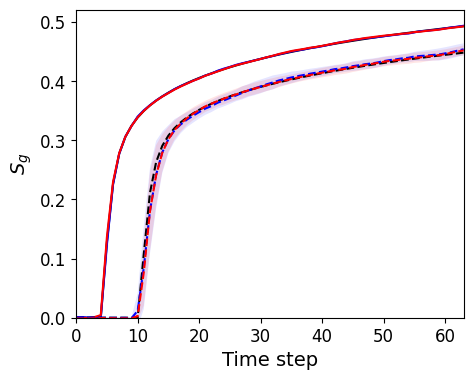

In [306]:
plt.figure(figsize=(5, 4))

# ---------probed point-----------
plt.plot(range(64), sparse20_ref, color='k', linewidth=1.5)

plt.plot(range(64), sparse20_sat_mean, color='blue', linewidth=1.5)
plt.fill_between(range(64), sparse20_sat_mean - sparse20_sat_std, sparse20_sat_mean + sparse20_sat_std, color='blue', alpha=0.1, edgecolor='none')

plt.plot(range(64), sparse_all20_sat_mean, color='red', linewidth=1.5)
plt.fill_between(range(64), sparse_all20_sat_mean - sparse_all20_sat_std, sparse_all20_sat_mean + sparse_all20_sat_std, color='red', alpha=0.1,edgecolor='none')

# ---------unprobed point-----------
plt.plot(range(64), sparse20_ref_unprob, color='k', linewidth=1.5, ls='--')

plt.plot(range(64), sparse20_sat_mean_unprob, color='blue', linewidth=1.5, ls='--')
plt.fill_between(range(64), sparse20_sat_mean_unprob - sparse20_sat_std_unprob, sparse20_sat_mean_unprob + sparse20_sat_std_unprob, color='blue', alpha=0.1, edgecolor='none')

plt.plot(range(64), sparse_all20_sat_mean_unprob, color='red', linewidth=1.5, ls='--')
plt.fill_between(range(64), sparse_all20_sat_mean_unprob - sparse_all20_sat_std_unprob, sparse_all20_sat_mean_unprob + sparse_all20_sat_std_unprob, color='red', alpha=0.1, edgecolor='none')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Time step', fontsize=14)
plt.ylabel('$S_g$', fontsize=14)

plt.xlim(0, 63)
plt.ylim(bottom=0)
plt.savefig('conditional_outputs/figs_cart_sparse/Line_Cart_sparse20.pdf', bbox_inches='tight')
plt.show()

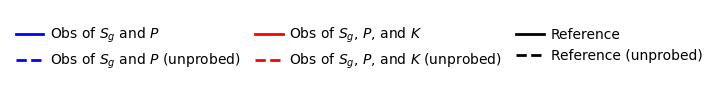

In [301]:
# 自定义 6 个图例元素
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, ls='-', label='Obs of $S_g$ and $P$'),
    Line2D([0], [0], color='blue', lw=2, ls='--', label='Obs of $S_g$ and $P$ (unprobed)'),
    Line2D([0], [0], color='red', lw=2, ls='-', label='Obs of $S_g$, $P$, and $K$'),
    Line2D([0], [0], color='red', lw=2, ls='--', label='Obs of $S_g$, $P$, and $K$ (unprobed)'),
    Line2D([0], [0], color='k', lw=2, ls='-', label='Reference'),
    Line2D([0], [0], color='k', lw=2, ls='--', label='Reference (unprobed)')
]

# 创建一个空的透明 subplot
fig, ax = plt.subplots(figsize=(6, 1))
ax.axis('off')

# 添加图例：2 行 3 列
fig.legend(
    handles=legend_elements,
    loc='center',
    ncol=3,
    frameon=False,
    handlelength=2,
    handletextpad=0.5,
    columnspacing=1.0,
    labelspacing=0.5,
)

# plt.tight_layout()
plt.savefig('conditional_outputs/figs_cart_sparse/Line_legend.pdf', bbox_inches='tight')
plt.show()

**Spatial variation of K**

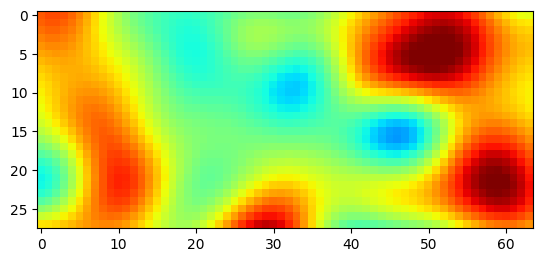

In [355]:
plt.imshow(ref[0, :28, :, -1],cmap='jet', vmin=1.5, vmax=6.5)

In [356]:
sparse1_k_line = sparse1_k[:, 32, :]
sparse_all1_k_line = sparse_all1_k[:, 32, :]
ref1_k_line = ref[0, 32, :, -1]

sparse5_k_line = sparse5_k[:, 28, :]
sparse_all5_k_line = sparse_all5_k[:, 28, :]
ref5_k_line = ref[0, 28, :, -1]

sparse20_k_line = sparse20_k[:, 37, :]
sparse_all20_k_line = sparse_all20_k[:, 37, :]
ref20_k_line = ref[1, 37, :, -1]

In [358]:
def compute_mean_std(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    return mean, std
def plot_line_and_fill(data, color):
    mean, std = compute_mean_std(data)
    plt.plot(range(64), mean, color=color, linewidth=1.5, ls='--')
    plt.fill_between(range(64), mean - std, mean + std, color=color, alpha=0.1, edgecolor='none')

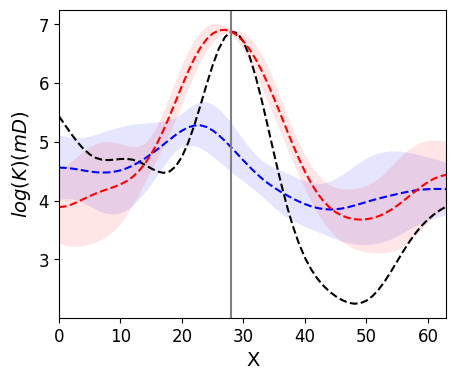

In [359]:
plt.figure(figsize=(5, 4))
plt.plot(range(64), ref1_k_line, color='k', linewidth=1.5, ls='--')

plot_line_and_fill(sparse1_k_line, 'blue')
plot_line_and_fill(sparse_all1_k_line, 'red')
plt.axvline(28, color='gray', linestyle='-', linewidth=1.5)
# plt.scatter(28, ref1_k_line[28], color='green', marker='o', s=50, zorder=101)

plt.xlim(0, 63)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('X', fontsize=14)
plt.ylabel('$log(K) (mD)$', fontsize=14)
plt.savefig('conditional_outputs/figs_cart_sparse/Line_spatial_K1.pdf', bbox_inches='tight')
plt.show()

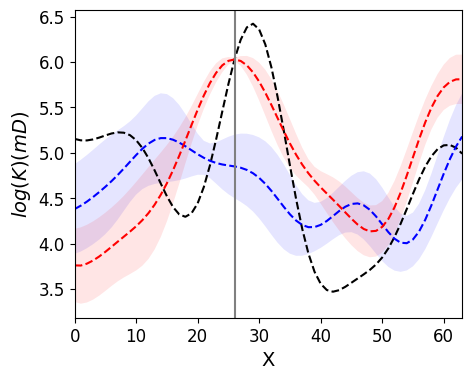

In [361]:
plt.figure(figsize=(5, 4))
plt.plot(range(64), ref5_k_line, color='k', linewidth=1.5, ls='--')
plot_line_and_fill(sparse5_k_line, 'blue')
plot_line_and_fill(sparse_all5_k_line, 'red')
plt.axvline(26, color='gray', linestyle='-', linewidth=1.5)

plt.xlim(0, 63)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('X', fontsize=14)
plt.ylabel('$log(K) (mD)$', fontsize=14)
plt.savefig('conditional_outputs/figs_cart_sparse/Line_spatial_K5.pdf', bbox_inches='tight')
plt.show()

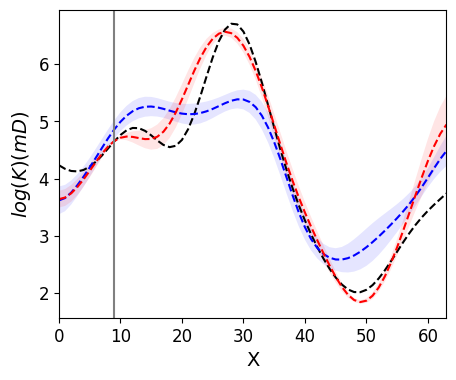

In [362]:
plt.figure(figsize=(5, 4))
plt.plot(range(64), ref20_k_line, color='k', linewidth=1.5, ls='--')
plot_line_and_fill(sparse20_k_line, 'blue')
plot_line_and_fill(sparse_all20_k_line, 'red')
plt.axvline(9, color='gray', linestyle='-', linewidth=1.5)

plt.xlim(0, 63)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('X', fontsize=14)
plt.ylabel('$log(K) (mD)$', fontsize=14)
plt.savefig('conditional_outputs/figs_cart_sparse/Line_spatial_K20.pdf', bbox_inches='tight')
plt.show()